In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/car_detection/Annotations.zip

In [ ]:
import torch
from torch.utils.data import DataLoader,Subset
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import pandas as pd
import cv2,os
import matplotlib.pyplot as plt

In [ ]:
img_path = os.path.join("Images/20160331_NTU_00073"+".png") #20161225_TPZ_00339
img = cv2.imread(img_path)# Load your image here

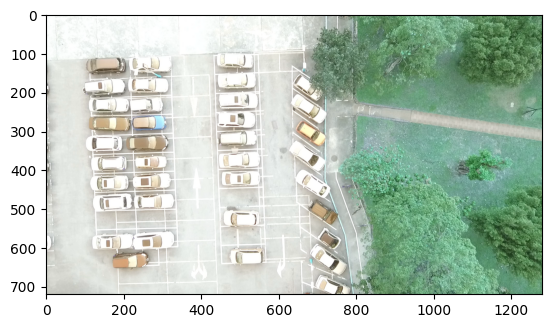

In [ ]:
plt.imshow(img) #cv2 reads img in bgr

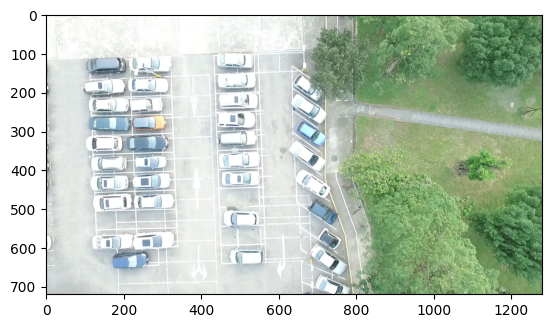

In [ ]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

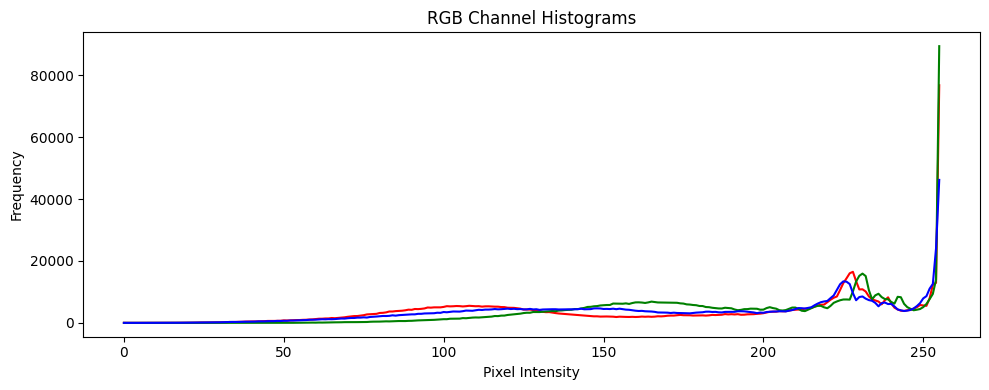

In [ ]:
# ----- RGB Histogram -----
colors = ('r', 'g', 'b')
plt.figure(figsize=(10, 4))
for i, col in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
    plt.title('RGB Channel Histograms')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

apply_clahe_to_rgb() to check clahe for 1 image

In [ ]:
def apply_clahe_to_rgb(image):
    # Assumes image is in RGB format (H, W, 3)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #overhead.. need to FIX in traning!!
    #plt.imshow(image_rgb)
    image_bgr = image  # OpenCV works in BGR
    #plt.imshow(image_bgr)
    b, g, r = cv2.split(image_bgr)

    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(4, 4))
    b_clahe = clahe.apply(b)
    g_clahe = clahe.apply(g)
    r_clahe = clahe.apply(r)

    merged = cv2.merge((b_clahe, g_clahe, r_clahe))
    enhanced_rgb = cv2.cvtColor(merged, cv2.COLOR_BGR2RGB)

   # Plot original and CLAHE image side by side
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title('Original RGB Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(enhanced_rgb)
    plt.title('CLAHE Enhanced Image')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Plot histogram of enhanced image
     # Plot histogram per RGB channel
    colors = ('r', 'g', 'b')
    plt.figure(figsize=(6, 4))
    for i, color in enumerate(colors):
        plt.hist(enhanced_rgb[:, :, i].ravel(), bins=256, range=[0, 256], color=color, alpha=0.5)
    plt.title('CLAHE Image Histogram (per channel)')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend(colors)
    plt.show()


    return enhanced_rgb

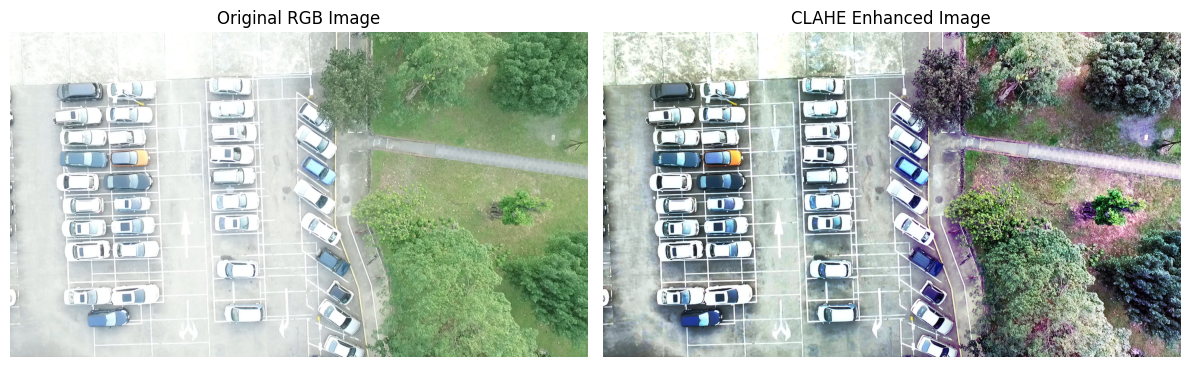

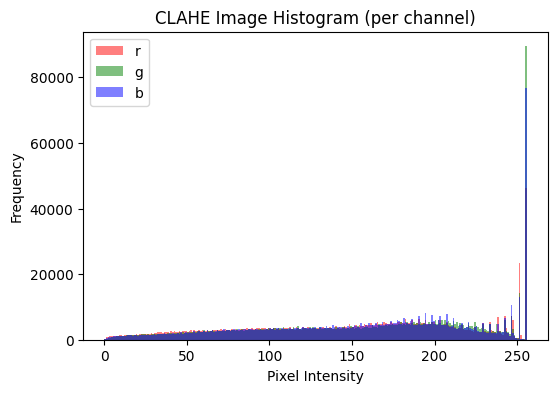

In [ ]:
enhanced_image = apply_clahe_to_rgb(img)

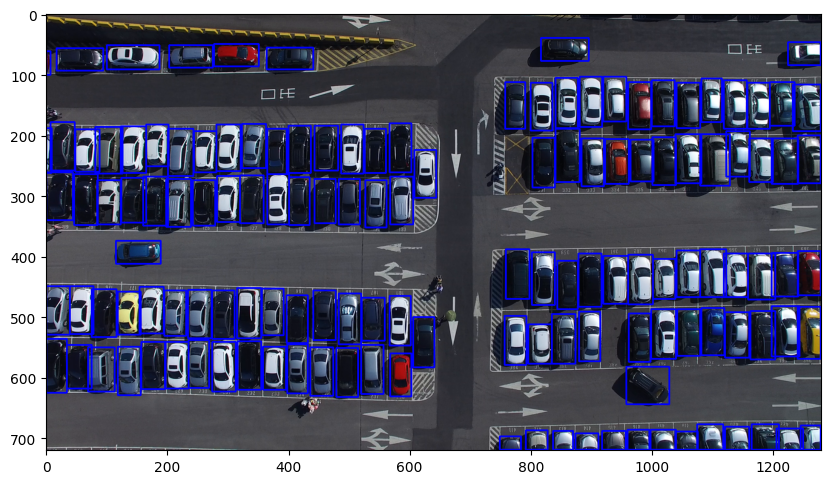

In [ ]:
img_path = os.path.join("Images/20161225_TPZ_00339"+".png")
img = cv2.imread(img_path)# Load your image here

annot_path = os.path.join("Annotations/20161225_TPZ_00339"+".txt")

# img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
df = pd.read_csv("Annotations/20161225_TPZ_00339.txt",header = None)

for row in df.iterrows():
  x1 = int(row[1][0].split(" ")[0])
  y1 = int(row[1][0].split(" ")[1])
  x2 = int(row[1][0].split(" ")[2])
  y2 = int(row[1][0].split(" ")[3])
  cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)
img_show = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img_show)


FASTER R-CNN

In [ ]:
model = fasterrcnn_resnet50_fpn(pretrained= True)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# Define transformations (e.g., resizing, normalization)
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet means #RGB
                std=[0.229, 0.224, 0.225])    # ImageNet stds
])


In [ ]:
path = "/content/drive/My Drive/car_detection/"
annot = "Annotations"
images = "Images"

apply_clahe_to_rgb() ----( removed code for  visualization)

In [ ]:
def apply_clahe_to_rgb(image):
    # OpenCV works in BGR
    b, g, r = cv2.split(image)

    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(4, 4))
    b_clahe = clahe.apply(b)
    g_clahe = clahe.apply(g)
    r_clahe = clahe.apply(r)

    merged = cv2.merge((b_clahe, g_clahe, r_clahe))
    enhanced_rgb = cv2.cvtColor(merged, cv2.COLOR_BGR2RGB)
    return enhanced_rgb

In [ ]:
# Custom Dataset class or using an existing one
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, transforms=None,use_clahe=True):
        # Initialize dataset paths and annotations here
        self.data=[]
        self.transforms = transforms
        self.use_clahe = use_clahe  # flexible flag
        # Your dataset logic (image paths, annotations, etc.)
        for file in os.listdir(images):
          self.data.append(os.path.splitext(file)[0])

    def __getitem__(self, idx):
        # Load image
        filename = self.data[idx]
        img_path = os.path.join(images,filename+".png")
        img = cv2.imread(img_path)# Load your image
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.use_clahe:  # conditionally apply CLAHE
            img = apply_clahe_to_rgb(img) #returns RGB

        # Apply transforms
        if self.transforms is not None:
            img = self.transforms(img)

        # Load corresponding bounding boxes and labels
        boxes = []  # Load or define bounding boxes
        labels = []  # Load or define labels

        annot_path = os.path.join(annot,filename+".txt")
        df = pd.read_csv(annot_path,header = None)
        for row in df.iterrows():
          x1 = int(row[1][0].split(" ")[0])
          y1 = int(row[1][0].split(" ")[1])
          x2 = int(row[1][0].split(" ")[2])
          y2 = int(row[1][0].split(" ")[3])
          l  = int(row[1][0].split(" ")[4])
          boxes.append([x1,y1,x2,y2])
          labels.append(l)


        # Create a target dictionary
        target = {}
        target["boxes"] = torch.tensor(boxes, dtype=torch.float32)
        target["labels"] = torch.tensor(labels, dtype=torch.int64)

        return img, target
    def __len__(self):
        # Return the length of your dataset
        return len(self.data)

Load Dataset

In [ ]:
#Data set split
dataset = CustomDataset(transforms=transform, use_clahe=True)
dataset_without_clahe = CustomDataset(transforms=transform, use_clahe=False)

total_images = len(dataset)
n_val = int(0.10*total_images)
n_test = int(0.10* total_images)
n_train = total_images - n_val - n_test

#For reproducability and comparing runs
torch.manual_seed(42)

#Create random permutation of all indices
all_indices = torch.randperm(total_images).tolist()

#Slice indices for each split
train_indices = all_indices[:n_train]
val_indices = all_indices[n_train: n_train+n_val]
test_indices = all_indices[n_train+n_val:]

#Create subsets
train_dataset = Subset(dataset, train_indices)
valid_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)

train_dataset_without_clahe = Subset(dataset_without_clahe, train_indices)
valid_dataset_without_clahe = Subset(dataset_without_clahe, val_indices)
test_dataset_without_clahe = Subset(dataset_without_clahe, test_indices)


#Create Data Loaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True,collate_fn = lambda x: tuple(zip(*x)))

valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False,
                                    collate_fn=lambda x: tuple(zip(*x)))
valid_annotation_paths = [os.path.join(annot,dataset.data[i]+".txt") for i in
                          val_indices]

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                                    collate_fn=lambda x: tuple(zip(*x)))
test_annotation_paths = [os.path.join(annot,dataset.data[i]+".txt") for i in
                          test_indices]

#Create Data Loader - Dataset without CLAHE
train_loader_without_clahe = DataLoader(train_dataset_without_clahe, batch_size = batch_size, shuffle = True,collate_fn = lambda x: tuple(zip(*x)))

valid_loader_without_clahe = DataLoader(valid_dataset_without_clahe, batch_size=batch_size, shuffle=False,
                                    collate_fn=lambda x: tuple(zip(*x)))
test_loader_without_clahe = DataLoader(test_dataset_without_clahe, batch_size=batch_size, shuffle=False,
                                    collate_fn=lambda x: tuple(zip(*x)))


Train with CLAHE, Validation with CLAHE

In [ ]:
def save_checkpoint(model, optimizer, epoch, val_loss, best_val_loss, path=''):
    if val_loss < best_val_loss:
        print(f"Validation loss improved ({best_val_loss:.4f} → {val_loss:.4f}). Saving model...")
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch, #Current epoch number. for resuming training later.
            'model_state_dict': model.state_dict(),  #weights and biases (learnable params)
            'optimizer_state_dict': optimizer.state_dict(), #Stores the internal state of the optimizer (e.g., learning rate, momentum, etc.).
            'val_loss': val_loss,
        }, path)
    return best_val_loss

Finally, since with normalization of pixels + CLAHE on training and validation data worked best, we train more epochs with this config.

In [ ]:
# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Set up the optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9,
                                                   weight_decay=0.0005)
# Learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3,
                                                               gamma=0.1)
#best_val_loss = float('inf') #if running model for the first time

#Load checkpoint
checkpoint = torch.load('/content/drive/MyDrive/car_detection/best_model_sg.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch = checkpoint['epoch'] + 1
best_val_loss = checkpoint['val_loss']

# Step the scheduler to match training progress so far
for _ in range(start_epoch):
    lr_scheduler.step()

print(f"Staring with Epoch {start_epoch} | "
          f"Best Validation Loss: {best_val_loss:.4f} | ")
for param_group in optimizer.param_groups:
    print(f"Starting Learning Rate: {param_group['lr']}")

num_epochs = 20
train_losses = []
val_losses   = []

for epoch in range(start_epoch, num_epochs):
    model.train()
    running_train_loss = 0.0

    # ── A: TRAINING PHASE ────────────────────────────────────────────
    for imgs, targets in train_loader:
        imgs    = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        loss_dict = model(imgs, targets)
        loss = sum(l for l in loss_dict.values())
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * len(imgs)  # accumulate sum(loss) over all images

    # Compute average training loss for this epoch:
    avg_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # ── B: VALIDATION PHASE ──────────────────────────────────────────
    #model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for imgs, targets in valid_loader:
            imgs    = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(imgs, targets)
            loss = sum(l for l in loss_dict.values())
            running_val_loss += loss.item() * len(imgs)

    avg_val_loss = running_val_loss / len(valid_loader.dataset)
    val_losses.append(avg_val_loss)

    # Save best model
    best_val_loss = save_checkpoint(model, optimizer, epoch, avg_val_loss, best_val_loss, path='/content/drive/MyDrive/car_detection/best_model_sg.pth')

    # ── C: STEP LR SCHEDULER ───────────────────────────────────────────
    lr_scheduler.step()

    # (Optional) print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}")


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Staring with Epoch 19 | Best Validation Loss: 0.2982 | 
Starting Learning Rate: 1.0000000000000009e-15
Epoch 20/20 | Train Loss: 0.2855 | Val Loss: 0.3025


In [ ]:
!pip install torchmetrics

In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [ ]:
def load_best_model(model, optimizer=None, path='/content/drive/MyDrive/car_detection/best_model_sg.pth'):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f"Loaded model from epoch {checkpoint['epoch']} with val loss = {checkpoint['val_loss']:.4f}")
    return model

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [ ]:
checkpoint = torch.load('/content/drive/MyDrive/car_detection/best_model_sg.pth', map_location=device)
checkpoint.keys()

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss'])

In [ ]:
checkpoint['epoch']

18

In [ ]:
checkpoint['val_loss']

0.29823839912811917

In [ ]:
device

device(type='cuda')

Mean Avg Precision


In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
# Set model to evaluation mode
checkpoint = torch.load("/content/drive/MyDrive/car_detection/best_model_sg.pth")
model.load_state_dict(checkpoint['model_state_dict'])
model.roi_heads.detections_per_img = 300
model.to(device)
model.eval()

# Initialize mAP metric
metric_map_val = MeanAveragePrecision(iou_type="bbox")

map_scores = []

# Disable gradient calculation
with torch.no_grad():
    for imgs, targets in valid_loader:
        # Move data to device
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Get model predictions (for mAP)
        preds = model(imgs)  # No targets here → returns predictions

        # Compute mAP (move everything to CPU)
        preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
        targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
        metric_map_val.update(preds_cpu, targets_cpu)



# Compute mAP
map_result_val = metric_map_val.compute()
val_map = map_result_val["map"].item() #map_result_val["map"] is a tensor
map_scores.append(val_map)

# Print detailed mAP metrics (optional)
print(map_result_val)


/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
/usr/local/l

{'map': tensor(0.7256), 'map_50': tensor(0.9003), 'map_75': tensor(0.8790), 'map_small': tensor(0.1483), 'map_medium': tensor(0.7341), 'map_large': tensor(0.7536), 'mar_1': tensor(0.0145), 'mar_10': tensor(0.1431), 'mar_100': tensor(0.7587), 'mar_small': tensor(0.2085), 'mar_medium': tensor(0.7685), 'mar_large': tensor(0.7783), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(1, dtype=torch.int32)}


INFERENCE using CLAHE on dataset

Loaded model from epoch 18 with val loss = 0.2982
Annotation_Path: Annotations/20161030_GF1_00092.txt


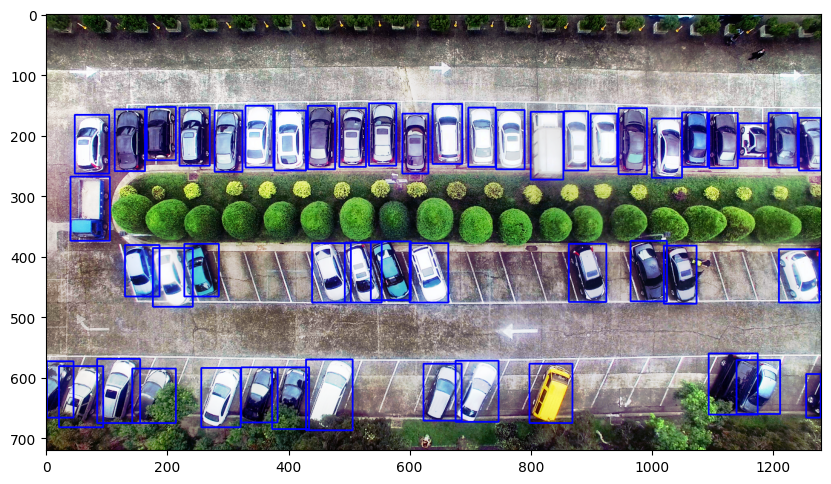

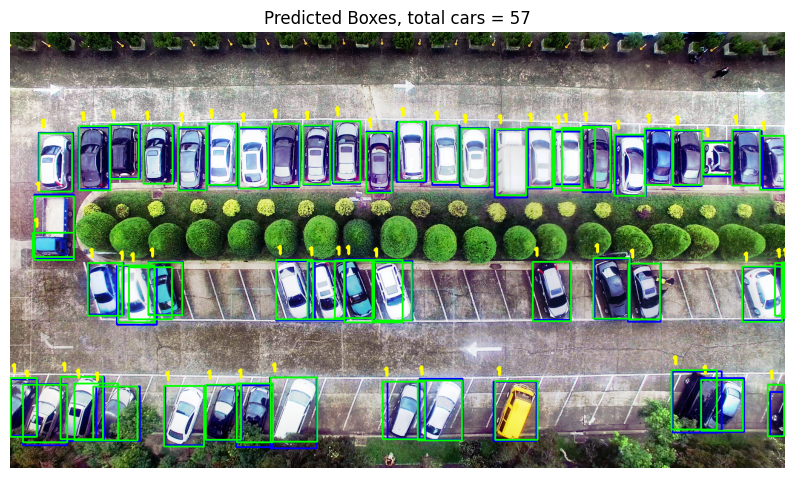

Annotation_Path: Annotations/20161030_GF2_00148.txt


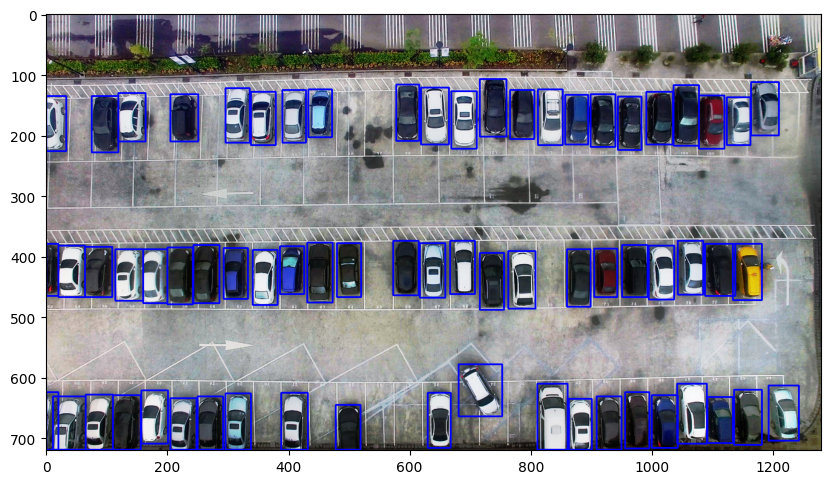

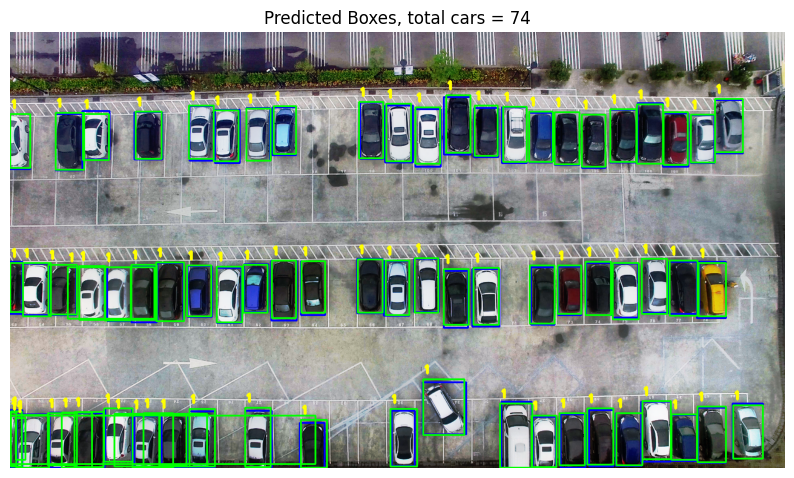

Annotation_Path: Annotations/20161030_GF2_00029.txt


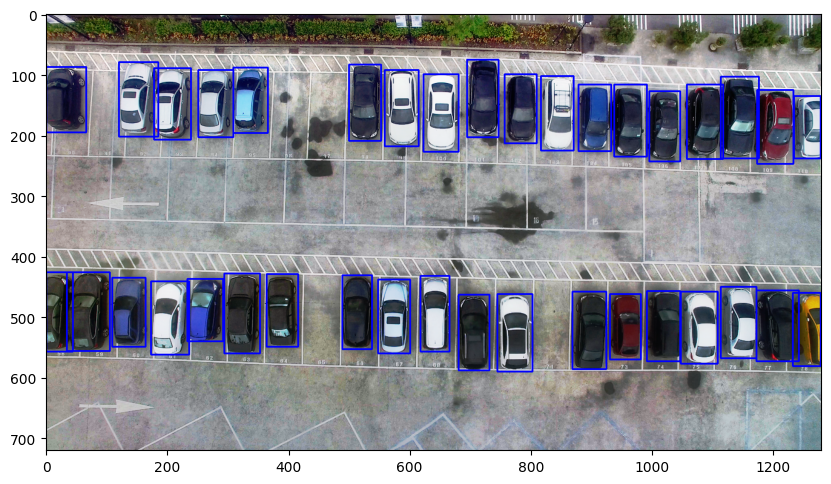

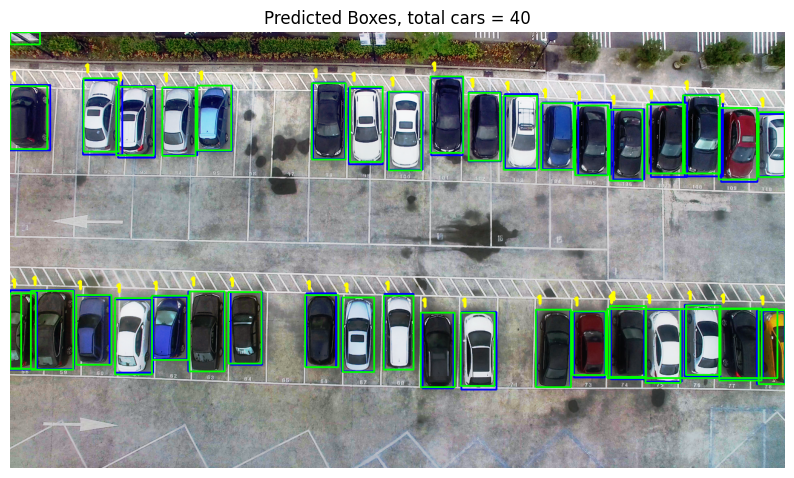

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Load weights from best checkpoint
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = load_best_model(model, path='/content/drive/MyDrive/car_detection/best_model_sg.pth')
model.roi_heads.detections_per_img = 300
model.to(device)
model.eval()
ptr=0
# Load one batch from valid_loader
with torch.no_grad():
    # for imgs, targets in valid_loader[:3]:
    for i, (imgs, targets) in enumerate(test_loader):
        if i == 3:
          break
        imgs = list(img.to(device) for img in imgs)
        predictions = model(imgs)

        img_tensor = imgs[0].cpu()
        #Pytorch format C,H,W -> OpenCV/Numpy format H,W,C
        img_np = img_tensor.permute(1, 2, 0).numpy()

        img_np = img_np * np.array([0.229, 0.224, 0.225]).reshape((1,1,3)) + np.array([0.485, 0.456, 0.406]).reshape((1,1,3))

        img_np = (img_np * 255).astype(np.uint8)

        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

        boxes = predictions[0]['boxes'].cpu().numpy().astype(int)
        labels = predictions[0]['labels'].cpu().numpy()
        ann_path = test_annotation_paths[ptr]  # aligned with test_loader
        print("Annotation_Path:",ann_path)
        df = pd.read_csv(ann_path,header = None)

        for row in df.iterrows():
          x1 = int(row[1][0].split(" ")[0])
          y1 = int(row[1][0].split(" ")[1])
          x2 = int(row[1][0].split(" ")[2])
          y2 = int(row[1][0].split(" ")[3])
          cv2.rectangle(img_bgr,(x1,y1),(x2,y2),(255,0,0),2)
        img_show = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 10))
        plt.imshow(img_show)
        ptr+=len(imgs)

        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box
            cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
            # cv2.putText(img_bgr, f'{label}', (x1, y1 - 10),
            # # cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 4)  # outline
            cv2.putText(img_bgr, f'{label}', (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 4) #color is in BGR, thus here 0,255,255 means yellow

        # Convert back to RGB for displaying with matplotlib
        img_show = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 10))
        plt.imshow(img_show)
        plt.axis("off")
        plt.title(f"Predicted Boxes, total cars = {len(boxes)}")
        plt.show()

Performance on Test Data

In [ ]:
# 1. For loss computation, model must be in train() mode (even for eval)
model.train()

metric_map_val = MeanAveragePrecision(iou_type="bbox")
running_test_loss = 0.0

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Compute test loss (model expects targets only in train mode)
        loss_dict = model(imgs, targets)
        loss = sum(l for l in loss_dict.values())
        running_test_loss += loss.item() * len(imgs)

        # Switch to eval mode just for prediction
        model.eval()
        preds = model(imgs)
        model.train()

        # Compute mAP
        preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
        targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
        metric_map_val.update(preds_cpu, targets_cpu)

# Final results
avg_test_loss = running_test_loss / len(test_loader.dataset)
map_result_test = metric_map_val.compute()

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test mAP: {map_result_test['map'].item():.4f}")
print(map_result_test)


/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
/usr/local/l

Test Loss: 0.2907
Test mAP: 0.7176
{'map': tensor(0.7176), 'map_50': tensor(0.8904), 'map_75': tensor(0.8787), 'map_small': tensor(0.1350), 'map_medium': tensor(0.7345), 'map_large': tensor(0.8476), 'mar_1': tensor(0.0138), 'mar_10': tensor(0.1373), 'mar_100': tensor(0.7516), 'mar_small': tensor(0.1754), 'mar_medium': tensor(0.7682), 'mar_large': tensor(0.8667), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(1, dtype=torch.int32)}


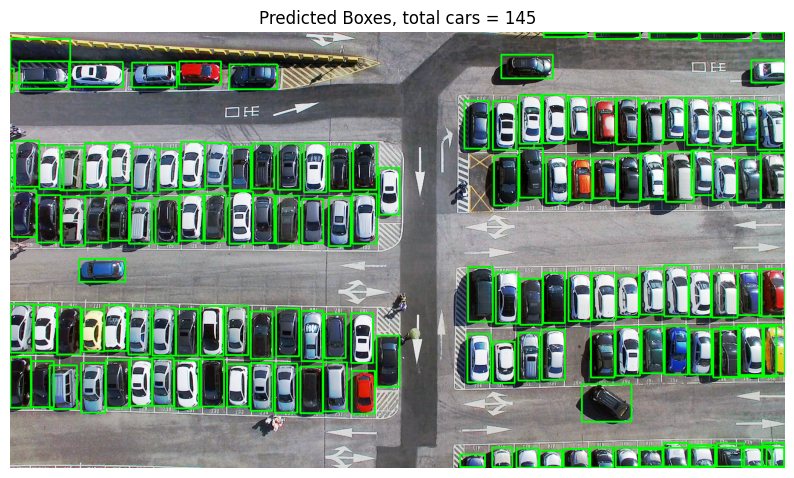

In [ ]:
import cv2

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

img = cv2.imread(images+"/"+"20161225_TPZ_00339.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = apply_clahe_to_rgb(img)
img = transform(img)
img = img.to(device)

# ─── 5) RUN FASTER R-CNN ─────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    predictions = model([img])   # note: a list of ONE [3,H,W] tensor

    img_tensor = img.cpu()
    #Pytorch format C,H,W -> OpenCV/Numpy format H,W,C
    img_np = img_tensor.permute(1, 2, 0).numpy()

    img_np = img_np * np.array([0.229, 0.224, 0.225]).reshape((1,1,3)) + np.array([0.485, 0.456, 0.406]).reshape((1,1,3))

    img_np = (img_np * 255).astype(np.uint8)

    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

    boxes = predictions[0]['boxes'].cpu().numpy().astype(int)
    labels = predictions[0]['labels'].cpu().numpy()

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)


    # Convert back to RGB for displaying with matplotlib
    img_show = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(img_show)
    plt.axis("off")
    plt.title(f"Predicted Boxes, total cars = {len(boxes)}")
    plt.show()

In [ ]:
model.roi_heads.detections_per_img

300

In [ ]:
print(model.roi_heads.nms_thresh)

0.5


-----END-------